In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:

# --- 1. Load Data ---
data_file = Path('../data/T100_domestic/processed/final_enriched_t100_data.parquet')
print(f"--- Loading data from {data_file} ---")
df = pd.read_parquet(data_file)

--- Loading data from ../data/T100_domestic/processed/final_enriched_t100_data.parquet ---


In [22]:
# there are many examples where ORIGIN == DEST or DISTANCE == 0. Origin = destination is understandable,
# but there are many cases where DISTANCE = 0 but ORIGIN != DEST, which seems like a data error.
df = df[(df.ORIGIN != df.DEST) & (df.DISTANCE != 0)].copy()
df['year_month'] = df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str).str.zfill(2)

In [23]:
df.columns

Index(['PASSENGERS', 'FREIGHT', 'MAIL', 'DISTANCE', 'UNIQUE_CARRIER',
       'AIRLINE_ID', 'UNIQUE_CARRIER_NAME', 'UNIQUE_CARRIER_ENTITY', 'REGION',
       'CARRIER', 'CARRIER_NAME', 'CARRIER_GROUP', 'CARRIER_GROUP_NEW',
       'ORIGIN_AIRPORT_ID', 'ORIGIN_AIRPORT_SEQ_ID', 'ORIGIN_CITY_MARKET_ID',
       'ORIGIN', 'ORIGIN_CITY_NAME', 'ORIGIN_STATE_ABR', 'ORIGIN_STATE_FIPS',
       'ORIGIN_STATE_NM', 'ORIGIN_COUNTRY', 'ORIGIN_COUNTRY_NAME',
       'ORIGIN_WAC', 'DEST_AIRPORT_ID', 'DEST_AIRPORT_SEQ_ID',
       'DEST_CITY_MARKET_ID', 'DEST', 'DEST_CITY_NAME', 'DEST_STATE_ABR',
       'DEST_STATE_FIPS', 'DEST_STATE_NM', 'DEST_COUNTRY', 'DEST_COUNTRY_NAME',
       'DEST_WAC', 'YEAR', 'QUARTER', 'MONTH', 'DISTANCE_GROUP', 'CLASS',
       'DATA_SOURCE', 'File_name', 'date', 'origin_airport_name',
       'origin_airport_type', 'origin_country_name', 'origin_continent',
       'origin_iso_country', 'dest_airport_name', 'dest_airport_type',
       'dest_country_name', 'dest_continent', 'dest_iso

/tmp/ipykernel_16717/2098123032.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  country_year_data = df.groupby(['ORIGIN_COUNTRY', 'YEAR']).agg({
/tmp/ipykernel_16717/2098123032.py:18: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  missing_pivot = country_year_data.pivot_table(


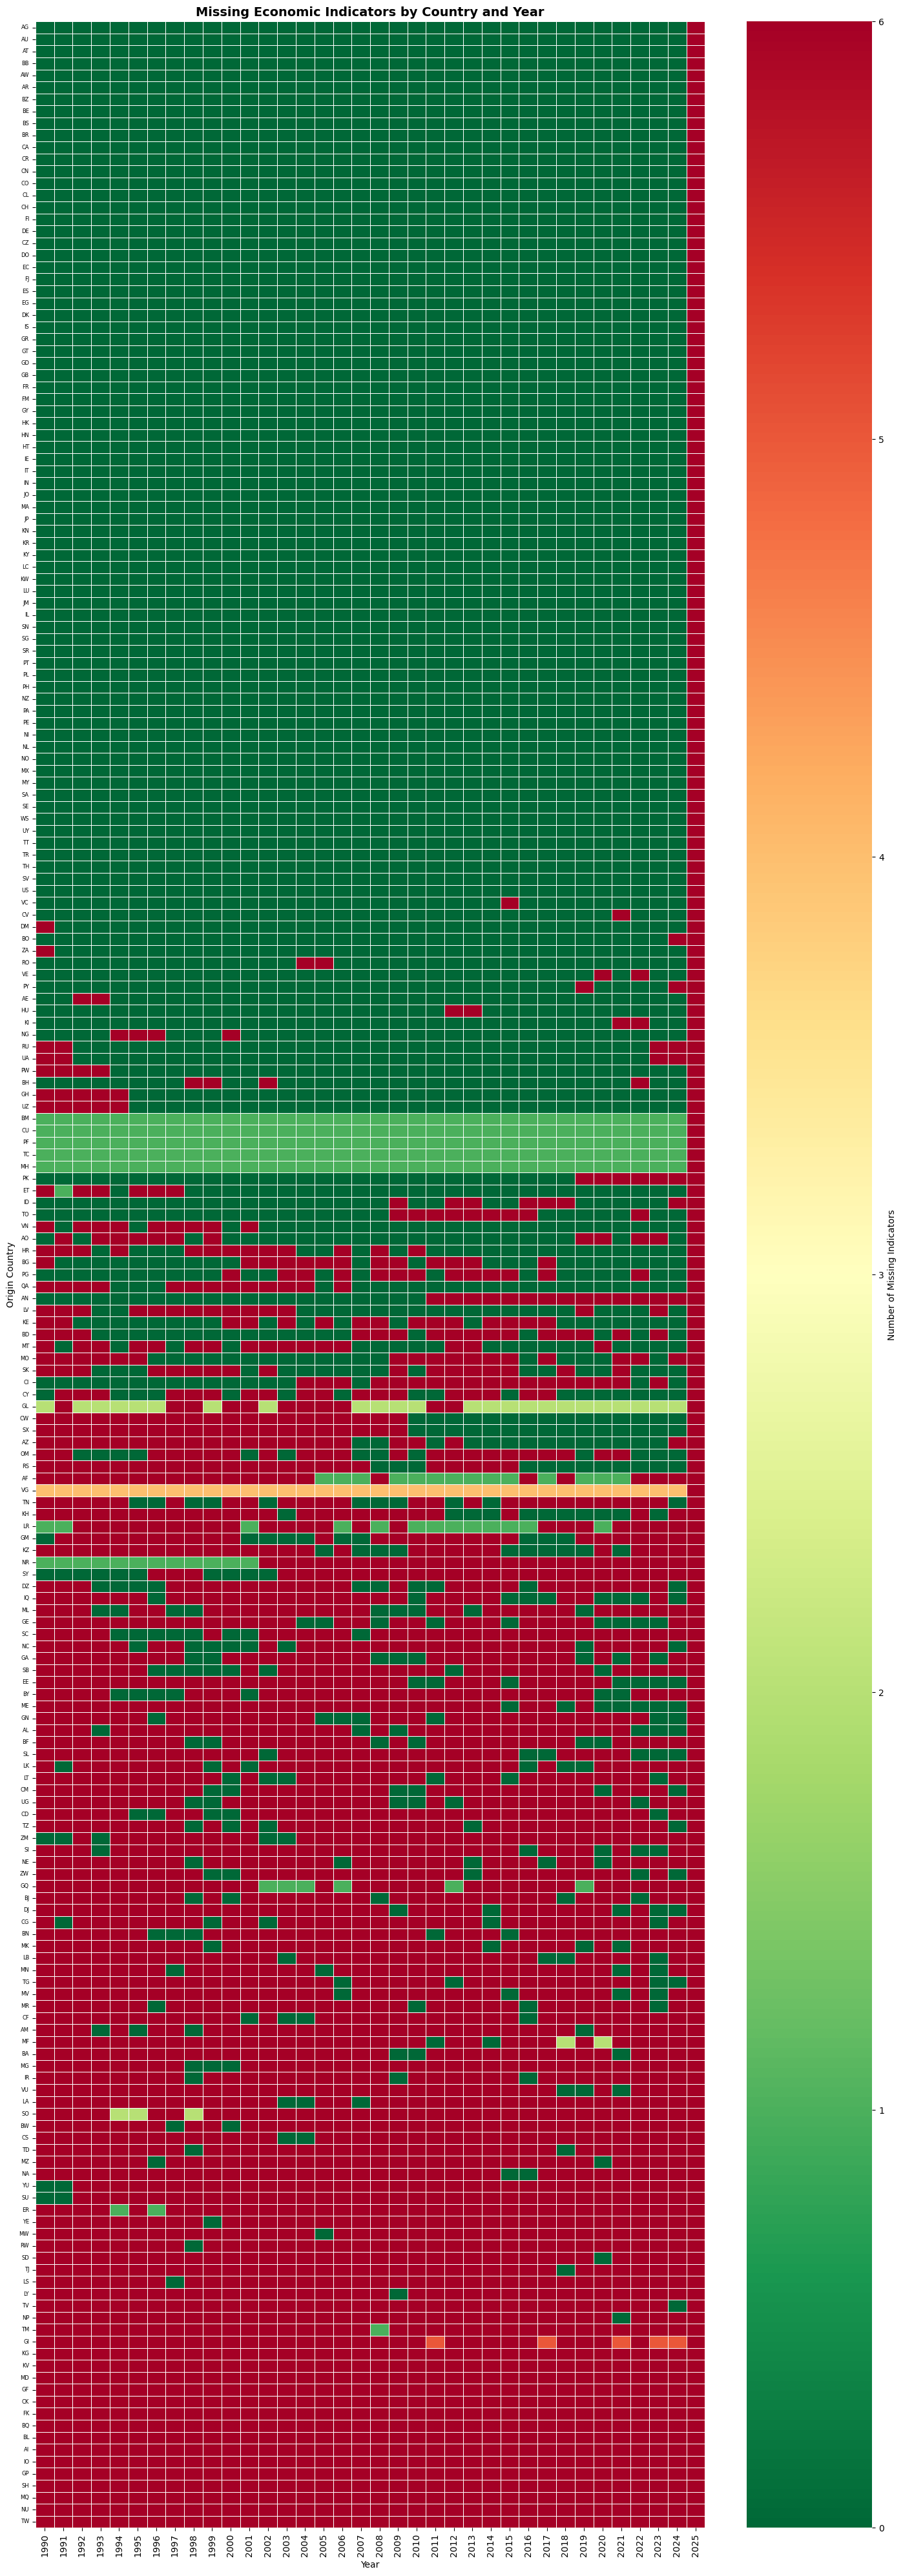

In [47]:
# Create a dataframe with unique country-year combinations and their economic data
country_year_data = df.groupby(['ORIGIN_COUNTRY', 'YEAR']).agg({
    'origin_inflation_cp': 'first',
    'origin_gdp': 'first',
    'origin_gdp_per_capita': 'first',
    'origin_population': 'first',
    'origin_tourism_arrivals': 'first',
    'origin_trade_pct_gdp': 'first'
}).reset_index()

# Count missing values for each indicator
country_year_data['missing_count'] = country_year_data[
    ['origin_inflation_cp', 'origin_gdp', 'origin_gdp_per_capita', 
     'origin_population', 'origin_tourism_arrivals', 'origin_trade_pct_gdp']
].isna().sum(axis=1)

# Create pivot table: rows=country, columns=year, values=missing_count
missing_pivot = country_year_data.pivot_table(
    index='ORIGIN_COUNTRY',
    columns='YEAR',
    values='missing_count',
    aggfunc='first'  # Each country-year combo appears only once
)

# Sort rows by total missing count (best to worst data completeness)
missing_pivot['total_missing'] = missing_pivot.sum(axis=1)
missing_pivot = missing_pivot.sort_values('total_missing').drop('total_missing', axis=1)

fig, ax = plt.subplots(figsize=(14, 40))

sns.heatmap(
    missing_pivot,
    cmap='RdYlGn_r',
    vmin=0,
    vmax=int(missing_pivot.max().max()),
    cbar_kws={'label': 'Number of Missing Indicators', 'ticks': range(0, int(missing_pivot.max().max()) + 1)},
    linewidths=0.5,
    annot=False,
    ax=ax
)
ax.set_title('Missing Economic Indicators by Country and Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Origin Country')

ax.set_yticklabels(ax.get_yticklabels(), fontsize=6, rotation=0)
fig.tight_layout()
plt.show()

In [24]:
df.CARRIER_NAME.unique()

['Trans Continental Airlines', 'Continental Air Lines Inc.', 'United Air Lines Inc.', 'Southwest Airlines Co.', 'Eastern Air Lines Inc.', ..., 'Western Aircraft, dba Lanai Air', 'LATAM Airlines Group SA dba Lan Airlines', 'Skyemotion GmbH', 'JetHouse', 'Arajet S.A.']
Length: 942
Categories (944, object): ['1263343 Alberta Inc. d/b/a Lynx Air', '1903 Aviation', '40-Mile Air', 'A/S Conair', ..., 'Zambia Airways Corp.', 'Zantop International', 'Zas Airline Of Egypt', 'Zuliana De Aviacion']

In [25]:
df_inbound = df[df['Travel_type'] == 'Inbound International'].copy()

<Axes: xlabel='DISTANCE', ylabel='PASSENGERS'>

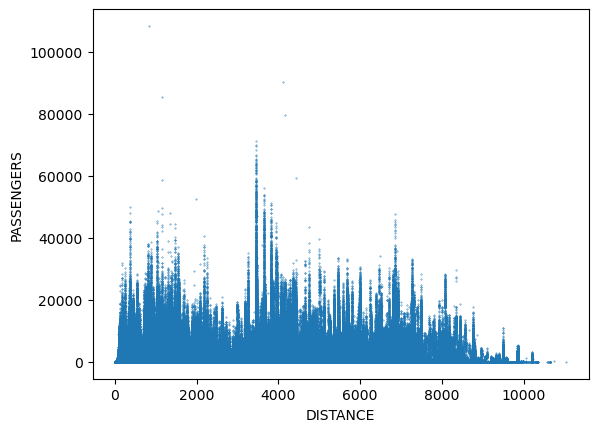

In [26]:
df_inbound.plot(x='DISTANCE', y='PASSENGERS', kind='scatter', s=0.1)

In [27]:
# --- 3. Select Features ---
# We pick features that plausibly drive demand for coming TO the US.
target_col = 'PASSENGERS'

numerical_features = [
    'DISTANCE',
    'origin_gdp',            # Wealthier countries should visit more
    'origin_population',     # Bigger countries should visit more
    'origin_gdp_per_capita', # Wealth per person might influence travel propensity
    #'U.S. Gulf Coast Kerosene-Type Jet Fuel Spot Price FOB (Dollars per Gallon)' # Cost of travel
]

# We treat MONTH as categorical to capture seasonality (Summer peaks vs Winter lows)
# We treat origin_continent as categorical to capture regional trends
categorical_features = ['origin_continent', 'year_month']
#categorical_features = []

# Create modeling dataframe
cols_to_keep = numerical_features + categorical_features + [target_col]
df_model = df_inbound[cols_to_keep].dropna()

In [28]:
df_model = df_model.groupby(numerical_features + categorical_features)[target_col].sum().reset_index().copy()

In [29]:
print(f'Number of rows: {len(df_model)}')
df_model.describe(include='all')

Number of rows: 660170


,DISTANCE,origin_gdp,origin_population,origin_gdp_per_capita,origin_continent,year_month,PASSENGERS
count,660170.0,6.601700e+05,6.601700e+05,660170.000000,660170,660170,660170.0
unique,<NA>,NaN,NaN,NaN,6,420,<NA>
top,<NA>,NaN,NaN,NaN,NA,2024-07,<NA>
freq,<NA>,NaN,NaN,NaN,345884,1920,<NA>
mean,2906.572213,1.162236e+12,8.093152e+07,23985.163449,NaN,NaN,3955.942042
std,2201.808954,1.828368e+12,2.055572e+08,20863.724046,NaN,NaN,7348.722293
min,2.0,2.261329e+07,9.622000e+03,96.319224,NaN,NaN,0.0
25%,1181.0,6.739639e+10,7.741694e+06,7135.222733,NaN,NaN,41.0
50%,2053.0,6.306080e+11,3.508099e+07,20186.798878,NaN,NaN,1073.0
75%,4401.0,1.556509e+12,8.443057e+07,39150.039631,NaN,NaN,4878.0


In [31]:
df_model

,DISTANCE,origin_gdp,origin_population,origin_gdp_per_capita,origin_continent,year_month,PASSENGERS
0,2,1.466465e+12,128613117.0,11402.141037,NA,2022-10,0
1,2,1.793799e+12,129739759.0,13826.130657,NA,2023-02,3
2,12,6.312494e+11,97115707.0,6499.971830,NA,1999-05,0
3,12,7.420613e+11,98625552.0,7524.027138,NA,2000-01,0
4,12,7.420613e+11,98625552.0,7524.027138,NA,2000-10,0
...,...,...,...,...,...,...,...
660165,10641,2.347725e+11,225048008.0,1043.210584,AS,2003-10,0
660166,10641,2.347725e+11,225048008.0,1043.210584,AS,2003-11,0
660167,10641,2.347725e+11,225048008.0,1043.210584,AS,2003-12,0
660168,10749,8.916338e+11,184688101.0,4827.781731,SA,2005-09,167


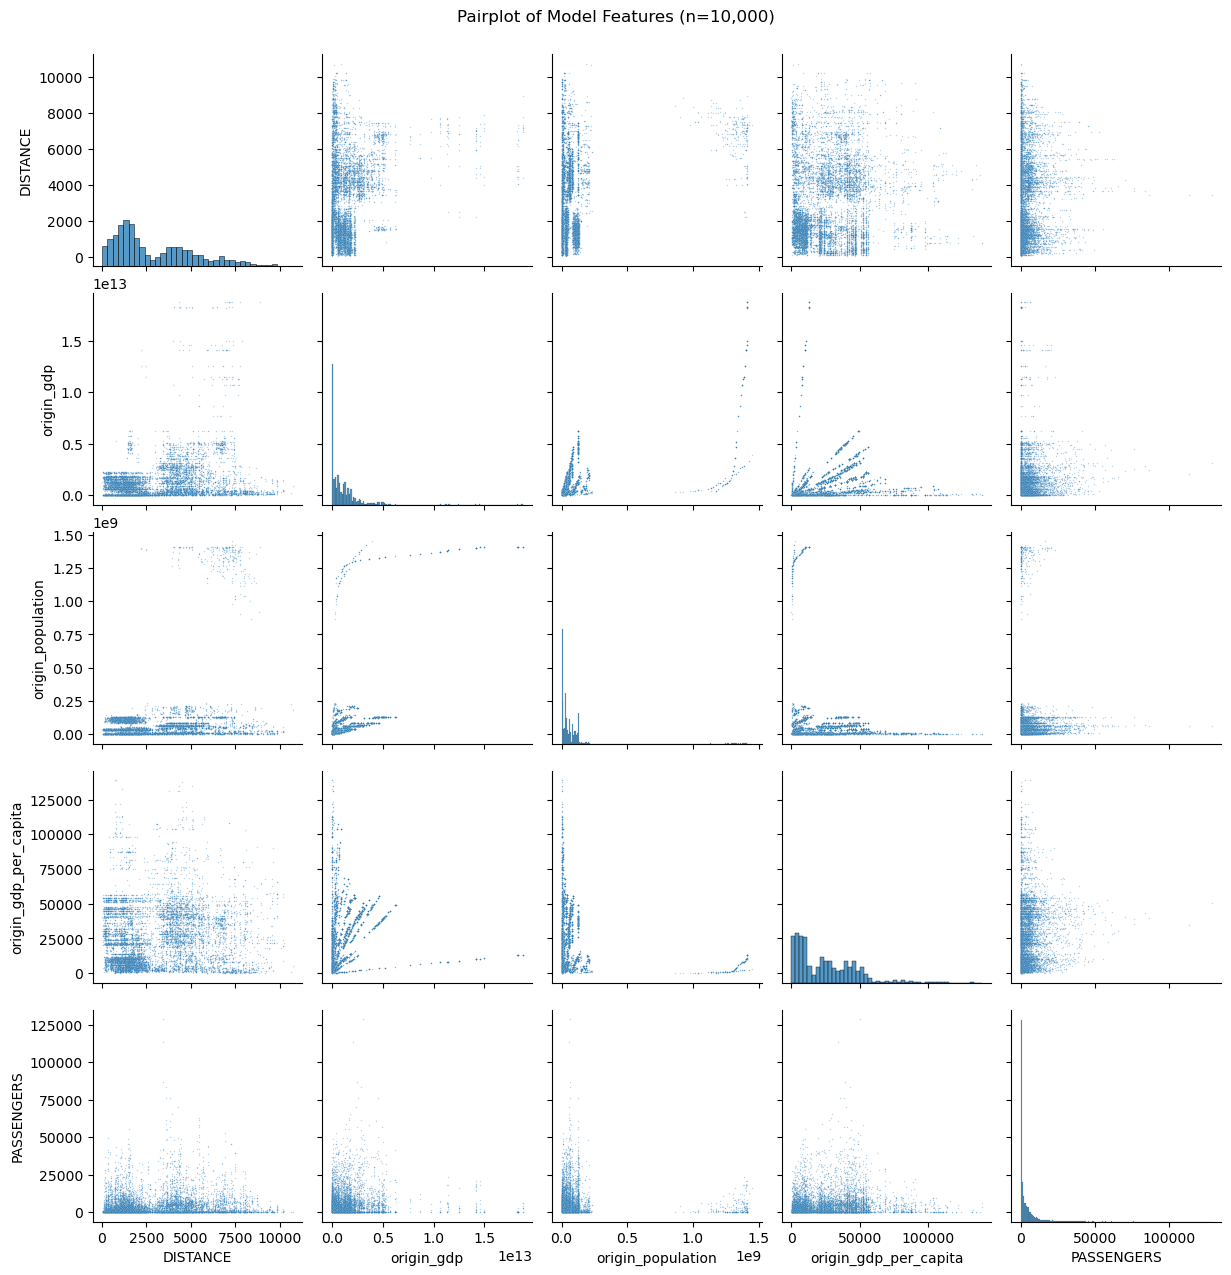

In [32]:
# Sample the data to speed up visualization
# 10,000 points is typically enough to see patterns
sample_size = min(10000, len(df_model))
df_sample = df_model.sample(n=sample_size, random_state=42)

sns.pairplot(df_sample, plot_kws={'alpha': 0.3, 's': 1})
plt.suptitle(f'Pairplot of Model Features (n={sample_size:,})', y=1.02)
plt.show()

In [33]:
df.groupby('ORIGIN', '')

,PASSENGERS,FREIGHT,MAIL,DISTANCE,UNIQUE_CARRIER,AIRLINE_ID,UNIQUE_CARRIER_NAME,UNIQUE_CARRIER_ENTITY,REGION,CARRIER,...,dest_inflation_cp,dest_gdp,dest_gdp_per_capita,dest_population,dest_tourism_arrivals,dest_trade_pct_gdp,U.S. Gulf Coast Kerosene-Type Jet Fuel Spot Price FOB (Dollars per Gallon),Travel_type,Travel_type_continent,year_month
44,0,0,0,10,YB (1),20283,Trans Continental Airlines,16903,I,YB,...,5.397956,5.963144e+12,23888.600009,249623000.0,79732000.0,15.270116,0.494,Domestic,Domestic,1990-06
45,0,0,0,10,YB (1),20283,Trans Continental Airlines,16903,I,YB,...,5.397956,5.963144e+12,23888.600009,249623000.0,79732000.0,15.270116,0.494,Domestic,Domestic,1990-06
46,0,0,0,10,YB (1),20283,Trans Continental Airlines,16903,I,YB,...,5.397956,5.963144e+12,23888.600009,249623000.0,79732000.0,15.270116,0.535,Domestic,Domestic,1990-07
47,0,0,0,11,CO,19704,Continental Air Lines Inc.,10221,P,CO,...,NaN,1.284000e+09,19227.889425,43342.0,676000.0,114.563863,0.971,Domestic,Domestic,1990-11
48,0,0,0,11,CO,19704,Continental Air Lines Inc.,10221,P,CO,...,NaN,3.394000e+09,20909.959030,138610.0,1362000.0,15.910915,0.803,Domestic,Domestic,1990-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10179062,83663,87134,210,404,DL,19790,Delta Air Lines Inc.,01260,D,DL,...,NaN,NaN,NaN,NaN,NaN,NaN,2.094,Domestic,Domestic,2025-06
10179063,84275,562218,5,404,DL,19790,Delta Air Lines Inc.,01260,D,DL,...,NaN,NaN,NaN,NaN,NaN,NaN,2.069,Domestic,Domestic,2025-03
10179064,84832,204449,0,404,DL,19790,Delta Air Lines Inc.,01260,D,DL,...,NaN,NaN,NaN,NaN,NaN,NaN,2.069,Domestic,Domestic,2025-03
10179065,86078,58485,0,404,DL,19790,Delta Air Lines Inc.,01260,D,DL,...,NaN,NaN,NaN,NaN,NaN,NaN,1.928,Domestic,Domestic,2025-05


In [18]:
X = df_model.drop(target_col, axis=1)
y = df_model[target_col]

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 4. Build Pipeline ---
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    # handle_unknown='ignore' is crucial for Carriers that might only appear in test set
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore')) 
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# The Model
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [19]:
# --- 5. Train & Evaluate ---
print("--- Training Linear Regression... ---")
lr_pipeline.fit(X_train, y_train)

print("\n--- Evaluation Results ---")
preds = lr_pipeline.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"R-squared: {r2:.2%}")
print(f"RMSE: {rmse:,.0f} passengers per route/month")

# --- 6. Interpret Coefficients (The "Why") ---
# This part extracts the weights the model assigned to each feature
feature_names = (numerical_features + 
                 list(lr_pipeline.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .get_feature_names_out(categorical_features)))

coefs = lr_pipeline.named_steps['regressor'].coef_

df_coefs = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefs})
df_coefs['Abs_Coefficient'] = df_coefs['Coefficient'].abs()
print("\n--- Top 10 Drivers of Inbound Passenger Volume ---")
print(df_coefs.sort_values(by='Abs_Coefficient', ascending=False).head(10))

--- Training Linear Regression... ---

--- Evaluation Results ---
R-squared: 2.90%
RMSE: 3,681 passengers per route/month


NotFittedError: This OneHotEncoder instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

--- Generating Plots ---


/tmp/ipykernel_8636/3321022863.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_coefs, x='Coefficient', y='Feature', palette='viridis', ax=axes[2])


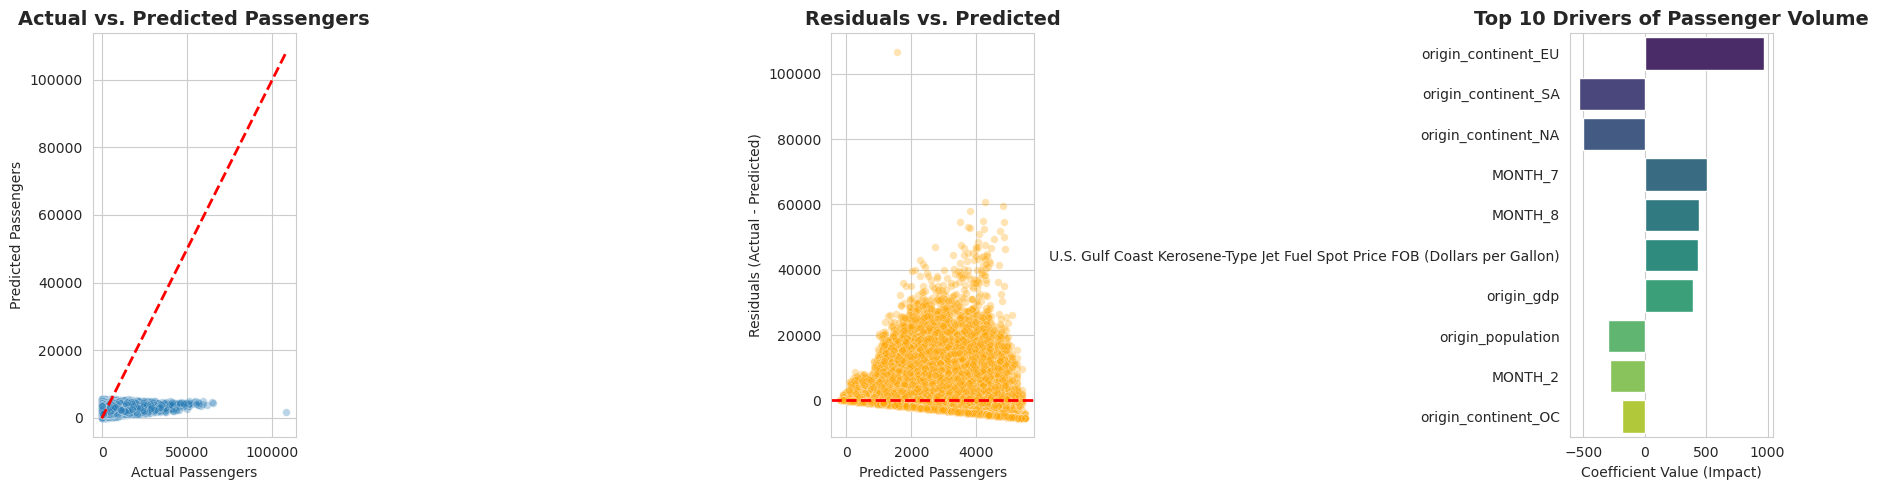

In [ ]:
# --- 6. PLOTTING ---
print("--- Generating Plots ---")
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Actual vs Predicted
# Ideally, all points lie on the red dashed line
sns.scatterplot(x=y_test, y=preds, alpha=0.3, s=30, ax=axes[0])
min_val = min(y_test.min(), preds.min())
max_val = max(y_test.max(), preds.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
axes[0].set_title("Actual vs. Predicted Passengers", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Actual Passengers")
axes[0].set_ylabel("Predicted Passengers")

# Plot 2: Residuals vs Predicted
# We want a random cloud centered on 0. Patterns here indicate missing non-linear features.
residuals = y_test - preds
sns.scatterplot(x=preds, y=residuals, alpha=0.3, s=30, color='orange', ax=axes[1])
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_title("Residuals vs. Predicted", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Predicted Passengers")
axes[1].set_ylabel("Residuals (Actual - Predicted)")

# Plot 3: Top Feature Coefficients
# Extract feature names from the pipeline
feature_names = (numerical_features + 
                 list(lr_pipeline.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .get_feature_names_out(categorical_features)))
coefs = lr_pipeline.named_steps['regressor'].coef_
df_coefs = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefs})
df_coefs['Abs_Coefficient'] = df_coefs['Coefficient'].abs()

# Sort by absolute impact
top_coefs = df_coefs.sort_values(by='Abs_Coefficient', ascending=False).head(10)

sns.barplot(data=top_coefs, x='Coefficient', y='Feature', palette='viridis', ax=axes[2])
axes[2].set_title("Top 10 Drivers of Passenger Volume", fontsize=14, fontweight='bold')
axes[2].set_xlabel("Coefficient Value (Impact)")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()